In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# PATHS (tus archivos)
# =========================
PATH_DESOC   = "raw/desocupacion.csv"
PATH_REMUN   = "raw/IndiceRemuneraciones.csv"
PATH_INF_XLS = "raw/empleosInformales.xlsx"
PATH_INF_GEN = "raw/ocpacionInformal.csv"

START_DATE = pd.to_datetime("2018-01-01")

# =========================
# PALETA (sobria tipo Banxico)
# =========================
RED   = "#b22222"
BLUE  = "#1f4e79"
GREEN = "#0b7d3e"
BLACK = "#111111"
GRAY  = "#6b7280"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


In [2]:
# =========================
# MAPA DE MESES (INEGI suele venir con nombres en español)
# =========================
MONTH_MAP = {
    "ene": 1, "enero": 1,
    "feb": 2, "febrero": 2,
    "mar": 3, "marzo": 3,
    "abr": 4, "abril": 4,
    "may": 5, "mayo": 5,
    "jun": 6, "junio": 6,
    "jul": 7, "julio": 7,
    "ago": 8, "agosto": 8,
    "sep": 9, "sept": 9, "septiembre": 9,
    "oct": 10, "octubre": 10,
    "nov": 11, "noviembre": 11,
    "dic": 12, "diciembre": 12,
}

def _clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def parse_inegi_monthly_csv(path, period_col="Periodo"):
    """
    Lee CSVs tipo INEGI donde hay filas con el año (ej. '2018') y debajo meses ('Enero', ...).
    Devuelve df con columna 'date' (mensual) + columnas numéricas.
    """
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    # normaliza el nombre de la columna de periodo si viniera raro
    if period_col not in df.columns:
        # intenta encontrar algo parecido
        candidates = [c for c in df.columns if c.lower().startswith("period")]
        if not candidates:
            raise ValueError(f"No encontré columna de periodo. Columnas disponibles: {list(df.columns)}")
        period_col = candidates[0]

    out_rows = []
    current_year = None

    for _, row in df.iterrows():
        p = _clean_str(row[period_col])
        if not p:
            continue

        # ¿es año?
        if re.fullmatch(r"\d{4}", p):
            current_year = int(p)
            continue

        # ¿es mes?
        key = p.lower()
        if key in MONTH_MAP and current_year is not None:
            m = MONTH_MAP[key]
            date = pd.Timestamp(current_year, m, 1)

            rec = {"date": date}
            for c in df.columns:
                if c == period_col:
                    continue
                rec[c] = pd.to_numeric(row[c], errors="coerce")
            out_rows.append(rec)

    out = pd.DataFrame(out_rows).sort_values("date").reset_index(drop=True)
    return out

def parse_inegi_quarterly_csv(path, period_col="Periodo"):
    """
    CSV con filas de año ('2022') y debajo trimestre ('I','II','III','IV').
    Convierte a fechas en fin de trimestre: Mar/Jun/Sep/Dic.
    """
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    if period_col not in df.columns:
        candidates = [c for c in df.columns if c.lower().startswith("period")]
        if not candidates:
            raise ValueError(f"No encontré columna de periodo. Columnas disponibles: {list(df.columns)}")
        period_col = candidates[0]

    q_map = {"i": 3, "ii": 6, "iii": 9, "iv": 12}

    out_rows = []
    current_year = None

    for _, row in df.iterrows():
        p = _clean_str(row[period_col])
        if not p:
            continue

        if re.fullmatch(r"\d{4}", p):
            current_year = int(p)
            continue

        key = p.lower()
        if key in q_map and current_year is not None:
            month = q_map[key]
            date = pd.Timestamp(current_year, month, 1)

            rec = {"date": date}
            for c in df.columns:
                if c == period_col:
                    continue
                rec[c] = pd.to_numeric(row[c], errors="coerce")
            out_rows.append(rec)

    out = pd.DataFrame(out_rows).sort_values("date").reset_index(drop=True)
    return out

def banxico_axes(ax):
    """Estilo sobrio tipo Banxico (sin caja, spines limpios, ticks hacia afuera)."""
    ax.set_facecolor("white")
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    ax.tick_params(axis="both", which="both", direction="out", length=4, width=1)
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


In [3]:
# =========================
# (a) TASA DE OCUPACIÓN (100 - desocupación)
# =========================
des = parse_inegi_monthly_csv(PATH_DESOC, period_col="Periodo")

# Tus columnas vienen como: Total, Hombres, Mujeres
# (y están en % respecto a la PEA)
for c in ["Total", "Hombres", "Mujeres"]:
    if c not in des.columns:
        raise ValueError(f"Falta columna '{c}' en desocupación. Columnas: {list(des.columns)}")

occ = des[["date", "Total", "Hombres", "Mujeres"]].copy()
occ["Total"]   = 100 - occ["Total"]
occ["Hombres"] = 100 - occ["Hombres"]
occ["Mujeres"] = 100 - occ["Mujeres"]

occ = occ[occ["date"] >= START_DATE].reset_index(drop=True)
occ.head()


,date,Total,Hombres,Mujeres
0,2023-01-01,96.416267,96.327840,96.608744
1,2023-02-01,96.517114,96.790667,96.398824
2,2023-03-01,96.591252,96.343123,97.060730
3,2023-04-01,96.361815,96.109905,96.553459
4,2023-05-01,96.594062,96.693999,96.459258


In [4]:
# =========================
# (b) ÍNDICE DE REMUNERACIONES
# =========================
rem = parse_inegi_monthly_csv(PATH_REMUN, period_col="Periodo")

# En tu archivo la columna se llama "Índice"
idx_col = None
for cand in ["Índice", "Indice", "INDICE", "índice"]:
    if cand in rem.columns:
        idx_col = cand
        break
if idx_col is None:
    raise ValueError(f"No encontré columna de índice en remuneraciones. Columnas: {list(rem.columns)}")

rem = rem[["date", idx_col]].rename(columns={idx_col: "indice"}).copy()
rem = rem[rem["date"] >= START_DATE].reset_index(drop=True)
rem.head()


,date,indice
0,2018-01-01,98.800916
1,2018-02-01,99.244778
2,2018-03-01,99.476984
3,2018-04-01,100.557867
4,2018-05-01,101.018639


In [5]:
# =========================
# (c) EMPLEOS INFORMALES (Miles de unidades) - Excel
#   OJO: el Excel trae 2 bloques: niveles (miles) y luego "Variación porcentual".
#   Aquí NOS QUEDAMOS con el bloque de niveles.
# =========================
tab = pd.read_excel(PATH_INF_XLS, sheet_name="Tabulado", header=4)
tab.columns = [str(c).strip() for c in tab.columns]
tab["Concepto"] = tab["Concepto"].astype(str)

# corta justo antes de "Variación porcentual"
cut_idx = tab.index[tab["Concepto"].str.contains("Variación porcentual", case=False, na=False)]
if len(cut_idx) == 0:
    raise ValueError("No encontré el separador 'Variación porcentual' en el Excel; revisa el formato.")
tab_levels = tab.loc[:cut_idx[0]-1].copy()

# limpia columnas-año (ej. 2023R, 2024P)
year_cols = [c for c in tab_levels.columns if c != "Concepto"]

def _to_year(c):
    m = re.search(r"(\d{4})", str(c))
    return int(m.group(1)) if m else None

years = [_to_year(c) for c in year_cols]
if any(y is None for y in years):
    bad = [c for c,y in zip(year_cols, years) if y is None]
    raise ValueError(f"No pude parsear años en columnas: {bad}")

# helper: extraer una serie por concepto (match robusto)
def get_concept_series(levels_df, contains_text):
    m = levels_df["Concepto"].str.contains(contains_text, case=False, na=False)
    hits = levels_df.loc[m].copy()
    if hits.empty:
        raise ValueError(f"No encontré concepto que contenga: '{contains_text}'")
    # si hay duplicados, toma el primero (en niveles normalmente hay 1)
    row = hits.iloc[0]
    vals = pd.to_numeric(row[year_cols], errors="coerce").values.astype(float)
    s = pd.DataFrame({"year": years, "value": vals})
    s = s.dropna().sort_values("year")
    s["date"] = pd.to_datetime(s["year"].astype(int).astype(str) + "-01-01")
    return s[["date", "value"]].reset_index(drop=True)

inf_total = get_concept_series(tab_levels, r"^\s*Total\s*$|^\s*Total$|Total")
inf_com   = get_concept_series(tab_levels, "Comercio al por menor")
inf_cons  = get_concept_series(tab_levels, "Construcción")
inf_manuf = get_concept_series(tab_levels, "Industrias manufactureras")

# recorta a 2018+
inf_total = inf_total[inf_total["date"] >= START_DATE]
inf_com   = inf_com[inf_com["date"] >= START_DATE]
inf_cons  = inf_cons[inf_cons["date"] >= START_DATE]
inf_manuf = inf_manuf[inf_manuf["date"] >= START_DATE]

inf_total.head()


,date,value
15,2018-01-01,15998.572
16,2019-01-01,15757.976
17,2020-01-01,14836.796
18,2021-01-01,15794.496
19,2022-01-01,16023.332


In [6]:
# =========================
# (d) TASA DE INFORMALIDAD POR GÉNERO (trimestral)
# =========================
inf_g = parse_inegi_quarterly_csv(PATH_INF_GEN, period_col="Periodo")

for c in ["Total", "Hombres", "Mujeres"]:
    if c not in inf_g.columns:
        raise ValueError(f"Falta columna '{c}' en ocupacionInformal. Columnas: {list(inf_g.columns)}")

inf_g = inf_g[["date", "Total", "Hombres", "Mujeres"]].copy()
inf_g = inf_g[inf_g["date"] >= START_DATE].reset_index(drop=True)  # si empieza en 2022, se queda en 2022
inf_g.head()


,date,Total,Hombres,Mujeres
0,2022-03-01,28.352004,27.847165,29.128124
1,2022-06-01,28.603821,28.095084,29.345473
2,2022-09-01,28.215776,27.727030,28.968703
3,2022-12-01,28.084855,27.354883,29.158972
4,2023-03-01,28.281737,27.672999,29.193407


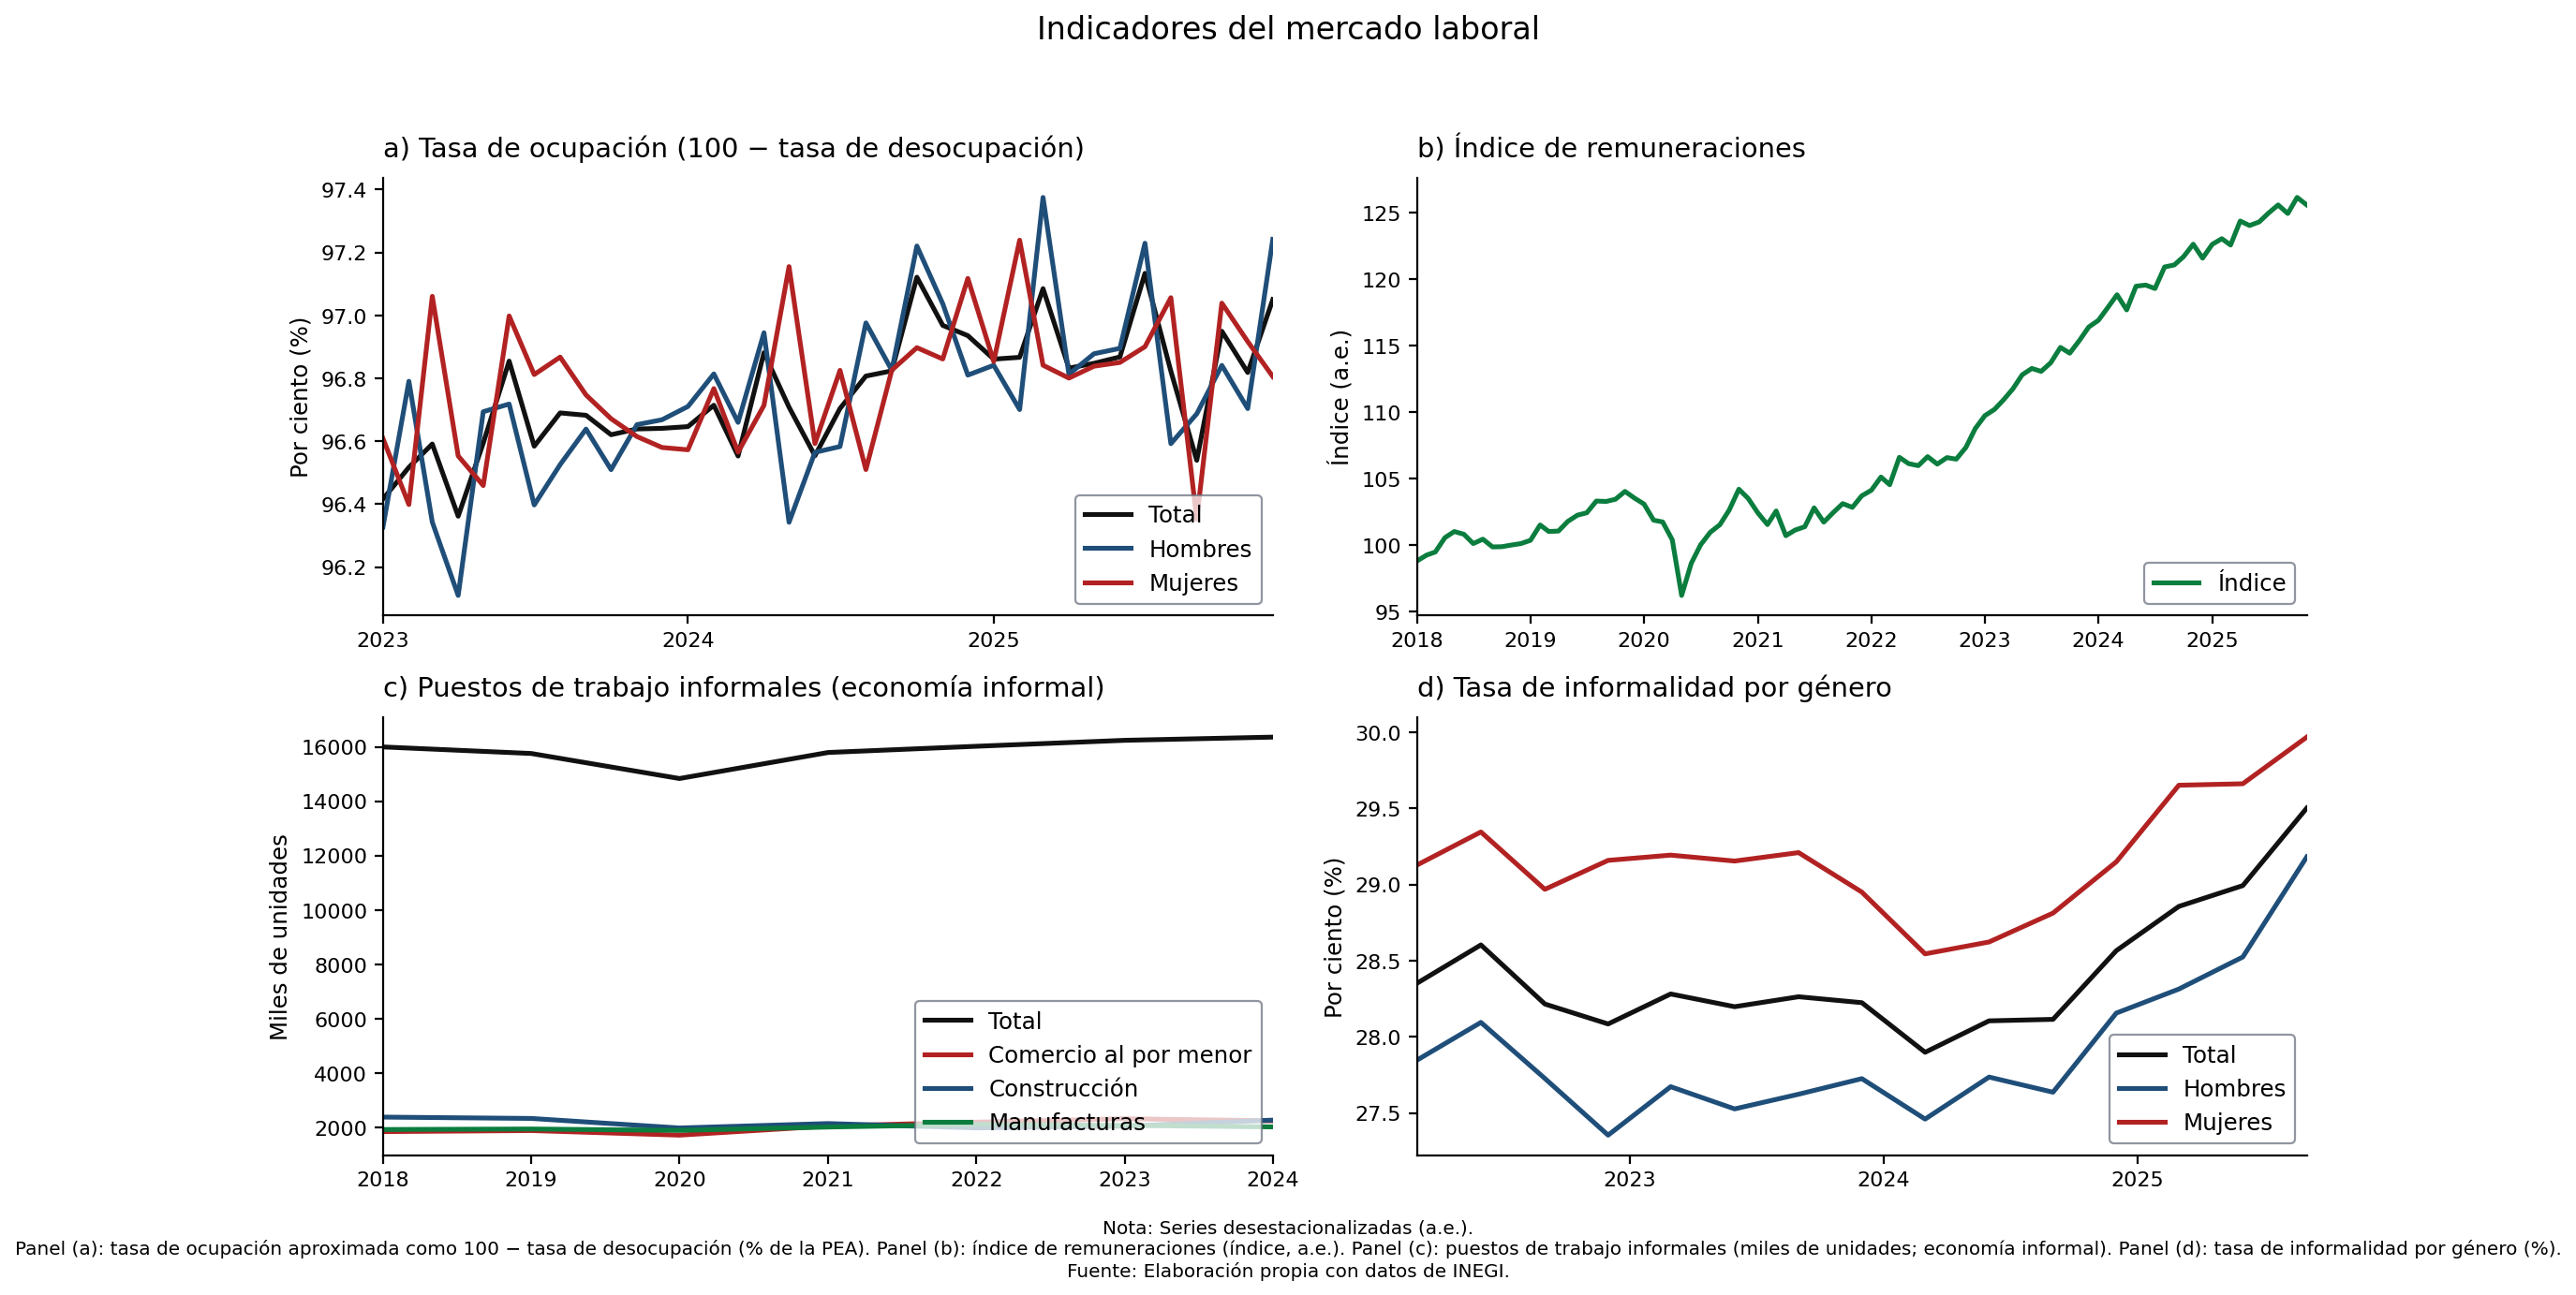

In [7]:
# =========================
# FIGURA 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14.5, 8.8), dpi=160)
(ax1, ax2), (ax3, ax4) = axes

LW = 2.3

# ---------- (a) Tasa de ocupación (100 - desocupación) ----------
banxico_axes(ax1)
ax1.set_title("a) Tasa de ocupación (100 − tasa de desocupación)", loc="left", pad=10)

ax1.plot(occ["date"], occ["Total"],   color=BLACK, lw=LW, label="Total")
ax1.plot(occ["date"], occ["Hombres"], color=BLUE,  lw=LW, label="Hombres")
ax1.plot(occ["date"], occ["Mujeres"], color=RED,   lw=LW, label="Mujeres")

ax1.set_ylabel("Por ciento (%)")
ax1.set_xlim(max(START_DATE, occ["date"].min()), occ["date"].max())
ax1.legend(frameon=True, framealpha=0.75, edgecolor=GRAY, loc="lower right")

# ---------- (b) Índice de remuneraciones ----------
banxico_axes(ax2)
ax2.set_title("b) Índice de remuneraciones", loc="left", pad=10)

ax2.plot(rem["date"], rem["indice"], color=GREEN, lw=LW, label="Índice")
ax2.set_ylabel("Índice (a.e.)")
ax2.set_xlim(max(START_DATE, rem["date"].min()), rem["date"].max())
ax2.legend(frameon=True, framealpha=0.75, edgecolor=GRAY, loc="lower right")

# ---------- (c) Empleos informales (miles) ----------
banxico_axes(ax3)
ax3.set_title("c) Puestos de trabajo informales (economía informal)", loc="left", pad=10)

ax3.plot(inf_total["date"], inf_total["value"], color=BLACK, lw=LW, label="Total")
ax3.plot(inf_com["date"],   inf_com["value"],   color=RED,   lw=LW, label="Comercio al por menor")
ax3.plot(inf_cons["date"],  inf_cons["value"],  color=BLUE,  lw=LW, label="Construcción")
ax3.plot(inf_manuf["date"], inf_manuf["value"], color=GREEN, lw=LW, label="Manufacturas")

ax3.set_ylabel("Miles de unidades")
xmin = max(START_DATE, min(inf_total["date"].min(), inf_com["date"].min(), inf_cons["date"].min(), inf_manuf["date"].min()))
xmax = max(inf_total["date"].max(), inf_com["date"].max(), inf_cons["date"].max(), inf_manuf["date"].max())
ax3.set_xlim(xmin, xmax)
ax3.legend(frameon=True, framealpha=0.75, edgecolor=GRAY, loc="lower right")

# ---------- (d) Informalidad por género ----------
banxico_axes(ax4)
ax4.set_title("d) Tasa de informalidad por género", loc="left", pad=10)

ax4.plot(inf_g["date"], inf_g["Total"],   color=BLACK, lw=LW, label="Total")
ax4.plot(inf_g["date"], inf_g["Hombres"], color=BLUE,  lw=LW, label="Hombres")
ax4.plot(inf_g["date"], inf_g["Mujeres"], color=RED,   lw=LW, label="Mujeres")

ax4.set_ylabel("Por ciento (%)")
if not inf_g.empty:
    ax4.set_xlim(max(START_DATE, inf_g["date"].min()), inf_g["date"].max())
ax4.legend(frameon=True, framealpha=0.75, edgecolor=GRAY, loc="lower right")

# ---------- Layout + nota ----------
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("")  # Banxico-style: sin xlabel (solo ticks de año)

fig.suptitle("Indicadores del mercado laboral", y=0.98, fontsize=15)

note = (
    "Nota: Series desestacionalizadas (a.e.).\n"
    "Panel (a): tasa de ocupación aproximada como 100 − tasa de desocupación (% de la PEA). "
    "Panel (b): índice de remuneraciones (índice, a.e.). "
    "Panel (c): puestos de trabajo informales (miles de unidades; economía informal). "
    "Panel (d): tasa de informalidad por género (%).\n"
    "Fuente: Elaboración propia con datos de INEGI."
)
fig.text(0.5, 0.02, note, ha="center", va="bottom", fontsize=9)

plt.tight_layout(rect=[0.02, 0.07, 0.98, 0.95])
plt.show()


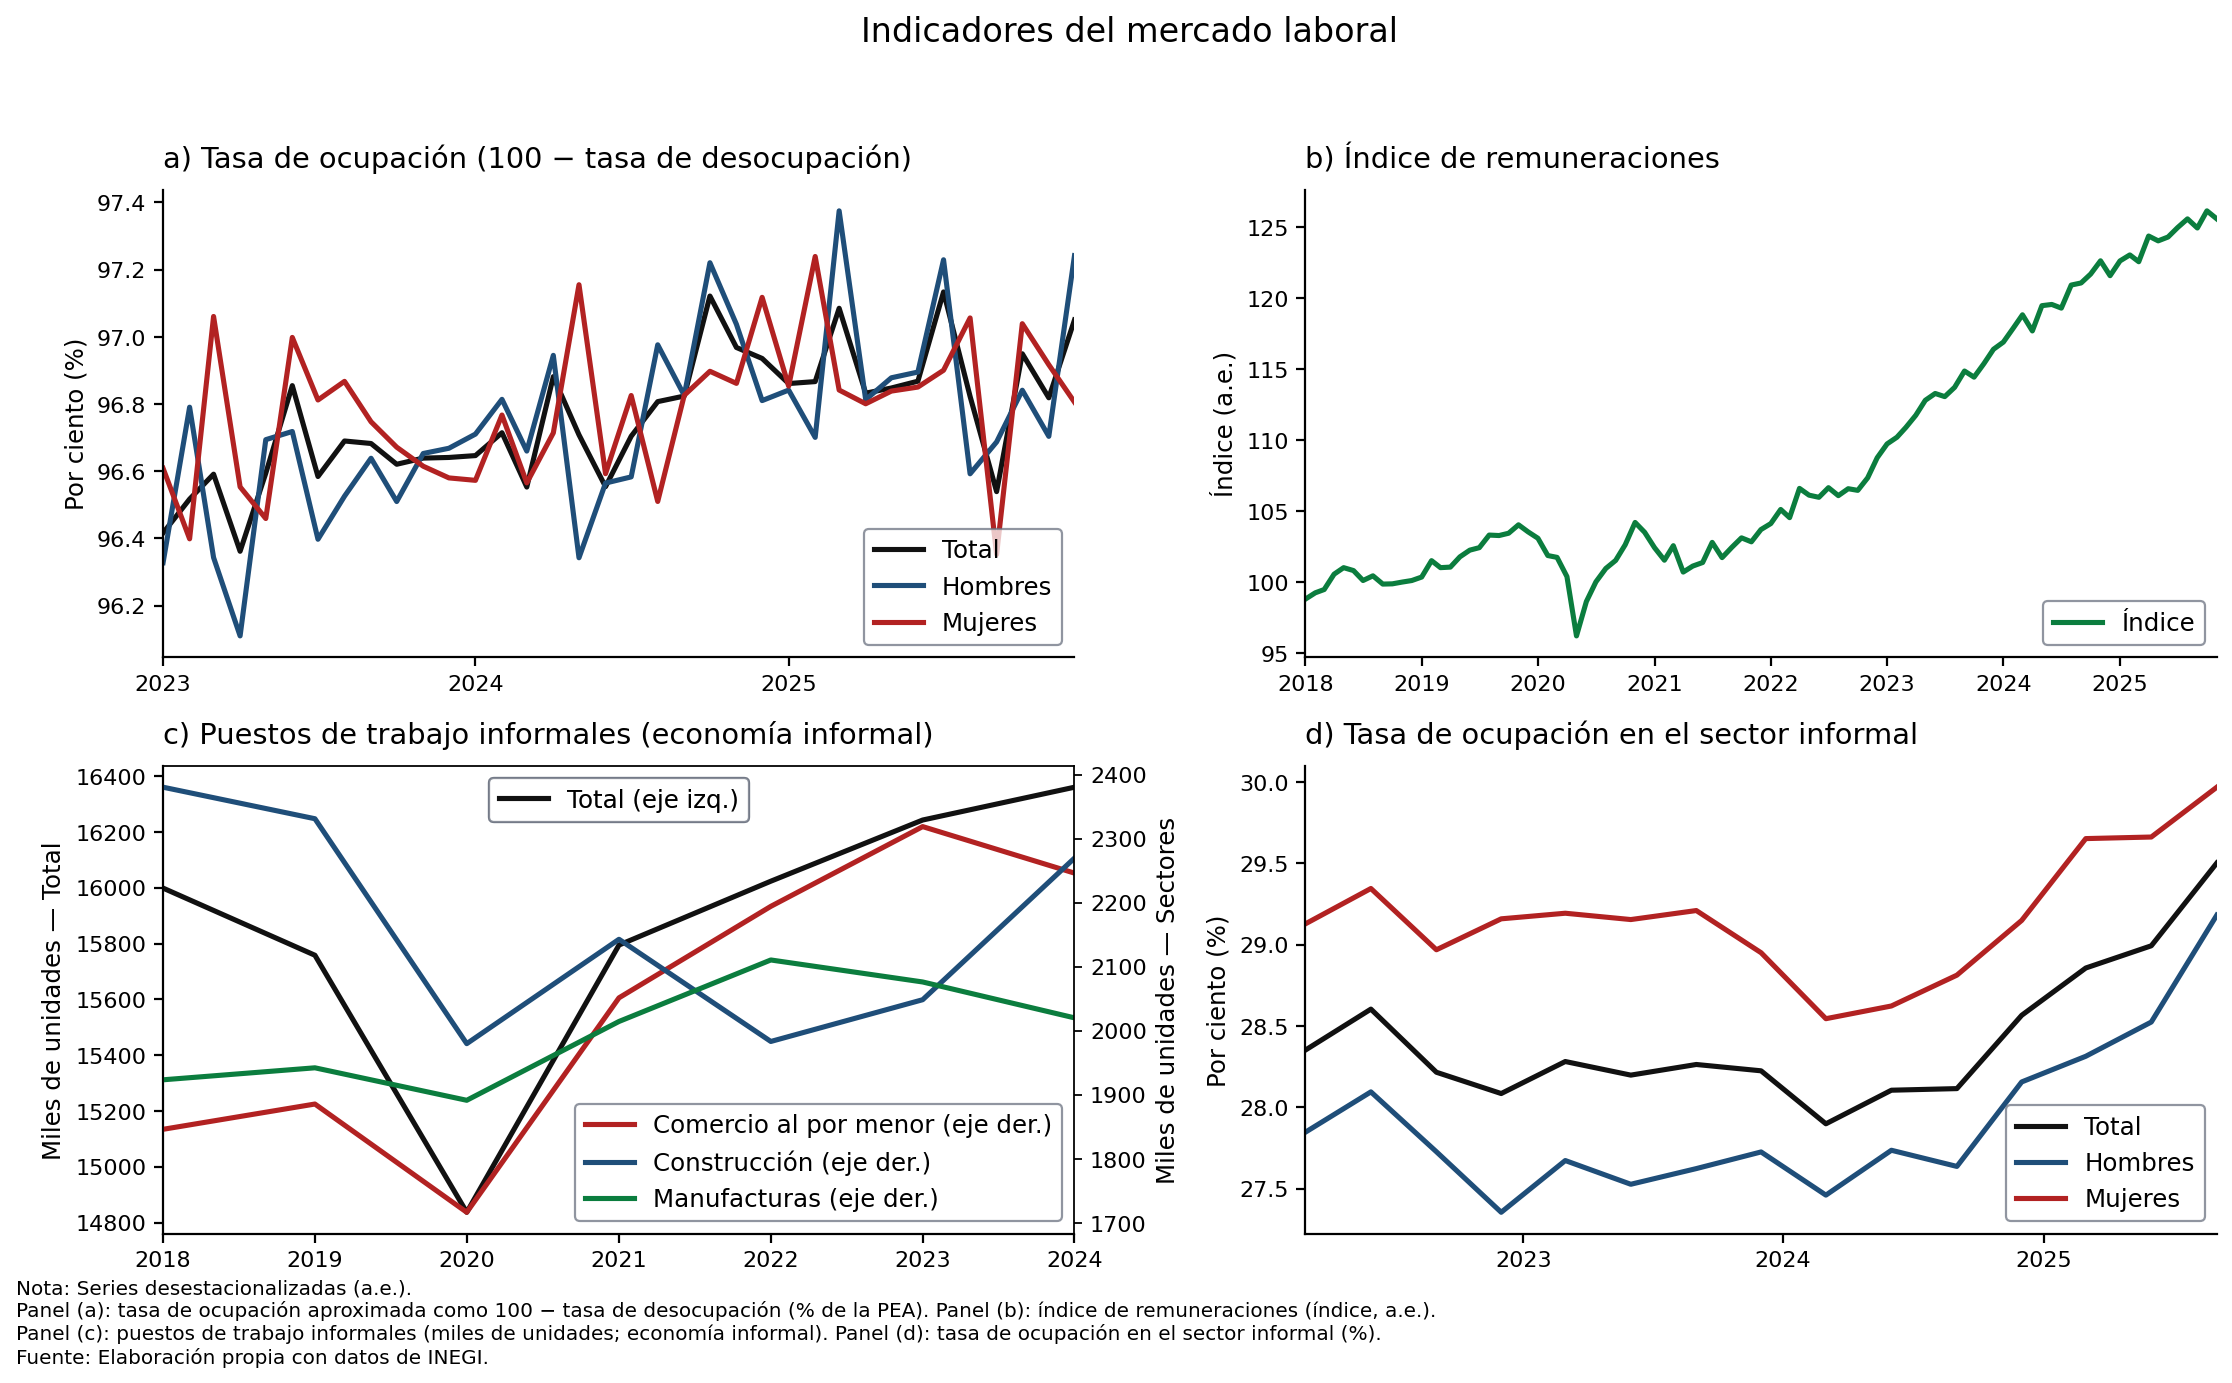

In [12]:
# =========================
# FIGURA 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14.5, 8.8), dpi=160)
(ax1, ax2), (ax3, ax4) = axes

LW = 2.3

# ---------- (a) Tasa de ocupación (100 - desocupación) ----------
banxico_axes(ax1)
ax1.set_title("a) Tasa de ocupación (100 − tasa de desocupación)", loc="left", pad=10)

ax1.plot(occ["date"], occ["Total"],   color=BLACK, lw=LW, label="Total")
ax1.plot(occ["date"], occ["Hombres"], color=BLUE,  lw=LW, label="Hombres")
ax1.plot(occ["date"], occ["Mujeres"], color=RED,   lw=LW, label="Mujeres")

ax1.set_ylabel("Por ciento (%)")
ax1.set_xlim(max(START_DATE, occ["date"].min()), occ["date"].max())
ax1.legend(frameon=True, framealpha=0.75, edgecolor=GRAY, loc="lower right")

# ---------- (b) Índice de remuneraciones ----------
banxico_axes(ax2)
ax2.set_title("b) Índice de remuneraciones", loc="left", pad=10)

ax2.plot(rem["date"], rem["indice"], color=GREEN, lw=LW, label="Índice")
ax2.set_ylabel("Índice (a.e.)")
ax2.set_xlim(max(START_DATE, rem["date"].min()), rem["date"].max())
ax2.legend(frameon=True, framealpha=0.75, edgecolor=GRAY, loc="lower right")

# ---------- (c) Empleos informales (miles) ----------
# ---------- (c) Empleos informales (doble eje) ----------
banxico_axes(ax3)
ax3.set_title(
    "c) Puestos de trabajo informales (economía informal)",
    loc="left",
    pad=10
)

# ---- eje izquierdo: TOTAL ----
l_total, = ax3.plot(
    inf_total["date"],
    inf_total["value"],
    color=BLACK,
    lw=LW,
    label="Total (eje izq.)"
)

ax3.set_ylabel("Miles de unidades — Total")

# ---- eje derecho: sectores ----
ax3b = ax3.twinx()

l_com, = ax3b.plot(
    inf_com["date"],
    inf_com["value"],
    color=RED,
    lw=LW,
    label="Comercio al por menor (eje der.)"
)

l_cons, = ax3b.plot(
    inf_cons["date"],
    inf_cons["value"],
    color=BLUE,
    lw=LW,
    label="Construcción (eje der.)"
)

l_man, = ax3b.plot(
    inf_manuf["date"],
    inf_manuf["value"],
    color=GREEN,
    lw=LW,
    label="Manufacturas (eje der.)"
)

ax3b.set_ylabel("Miles de unidades — Sectores")

# ---- rango común ----
xmin = max(
    START_DATE,
    min(
        inf_total["date"].min(),
        inf_com["date"].min(),
        inf_cons["date"].min(),
        inf_manuf["date"].min(),
    ),
)
xmax = max(
    inf_total["date"].max(),
    inf_com["date"].max(),
    inf_cons["date"].max(),
    inf_manuf["date"].max(),
)

ax3.set_xlim(xmin, xmax)

# ---- leyendas separadas por eje ----
leg1 = ax3.legend(
    handles=[l_total],
    frameon=True,
    framealpha=0.75,
    edgecolor=GRAY,
    loc="upper center",
)

leg2 = ax3b.legend(
    handles=[l_com, l_cons, l_man],
    frameon=True,
    framealpha=0.75,
    edgecolor=GRAY,
    loc="lower right",
)

ax3.add_artist(leg1)

# ---------- (d) Informalidad por género ----------
banxico_axes(ax4)
ax4.set_title("d) Tasa de ocupación en el sector informal", loc="left", pad=10)

ax4.plot(inf_g["date"], inf_g["Total"],   color=BLACK, lw=LW, label="Total")
ax4.plot(inf_g["date"], inf_g["Hombres"], color=BLUE,  lw=LW, label="Hombres")
ax4.plot(inf_g["date"], inf_g["Mujeres"], color=RED,   lw=LW, label="Mujeres")

ax4.set_ylabel("Por ciento (%)")
if not inf_g.empty:
    ax4.set_xlim(max(START_DATE, inf_g["date"].min()), inf_g["date"].max())
ax4.legend(frameon=True, framealpha=0.75, edgecolor=GRAY, loc="lower right")

# ---------- Layout + nota ----------
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("")  # Banxico-style: sin xlabel (solo ticks de año)

fig.suptitle("Indicadores del mercado laboral", y=0.98, fontsize=15)

note = (
    "Nota: Series desestacionalizadas (a.e.).\n"
    "Panel (a): tasa de ocupación aproximada como 100 − tasa de desocupación (% de la PEA). "
    "Panel (b): índice de remuneraciones (índice, a.e.). \n"
    "Panel (c): puestos de trabajo informales (miles de unidades; economía informal). "
    "Panel (d): tasa de ocupación en el sector informal (%).\n"
    "Fuente: Elaboración propia con datos de INEGI."
)
fig.text(0.02, 0.02, note, ha="left", va="bottom", fontsize=9)

plt.tight_layout(rect=[0.02, 0.07, 0.98, 0.95])
plt.show()

In [13]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.statespace.structural import UnobservedComponents

PATH_DESOC = "raw/desocupacion.csv"   # tu archivo
START_DATE = pd.to_datetime("2018-01-01")

RED   = "#b22222"
BLACK = "#111111"
GRAY  = "#6b7280"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


In [14]:
MONTH_MAP = {
    "ene": 1, "enero": 1,
    "feb": 2, "febrero": 2,
    "mar": 3, "marzo": 3,
    "abr": 4, "abril": 4,
    "may": 5, "mayo": 5,
    "jun": 6, "junio": 6,
    "jul": 7, "julio": 7,
    "ago": 8, "agosto": 8,
    "sep": 9, "sept": 9, "septiembre": 9,
    "oct": 10, "octubre": 10,
    "nov": 11, "noviembre": 11,
    "dic": 12, "diciembre": 12,
}

def _clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def parse_inegi_monthly_csv(path, period_col="Periodo"):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    if period_col not in df.columns:
        cand = [c for c in df.columns if c.lower().startswith("period")]
        if not cand:
            raise ValueError(f"No encontré columna 'Periodo'. Columnas: {list(df.columns)}")
        period_col = cand[0]

    out_rows = []
    current_year = None

    for _, row in df.iterrows():
        p = _clean_str(row[period_col])
        if not p:
            continue

        if re.fullmatch(r"\d{4}", p):
            current_year = int(p)
            continue

        key = p.lower()
        if key in MONTH_MAP and current_year is not None:
            date = pd.Timestamp(current_year, MONTH_MAP[key], 1)
            rec = {"date": date}
            for c in df.columns:
                if c == period_col:
                    continue
                rec[c] = pd.to_numeric(row[c], errors="coerce")
            out_rows.append(rec)

    out = pd.DataFrame(out_rows).sort_values("date").reset_index(drop=True)
    return out


In [15]:
des = parse_inegi_monthly_csv(PATH_DESOC, period_col="Periodo")

# tomamos TOTAL como tasa de desempleo/desocupación (a.e.)
if "Total" not in des.columns:
    raise ValueError(f"No encontré 'Total'. Columnas: {list(des.columns)}")

u = des[["date", "Total"]].rename(columns={"Total": "u"}).copy()
u = u.dropna().sort_values("date")
u = u[u["date"] >= START_DATE].reset_index(drop=True)

u.head(), u.tail()


(        date         u
 0 2023-01-01  3.583733
 1 2023-02-01  3.482886
 2 2023-03-01  3.408748
 3 2023-04-01  3.638185
 4 2023-05-01  3.405938,
          date         u
 31 2025-08-01  3.177219
 32 2025-09-01  3.460687
 33 2025-10-01  3.050244
 34 2025-11-01  3.181449
 35 2025-12-01  2.949695)

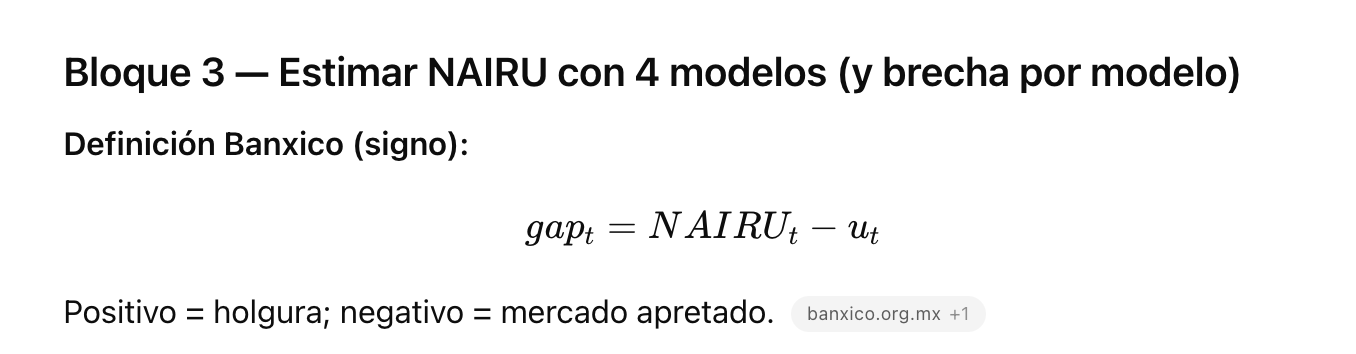


In [16]:
# Serie y_t para modelos
y = u.set_index("date")["u"].asfreq("MS")  # mensual inicio de mes

# =========================
# Modelo 1: HP (tendencia = NAIRU)
# lambda mensual (estándar): 129600
# =========================
cycle_hp, trend_hp = hpfilter(y, lamb=129600)
nairu_hp = trend_hp

# =========================
# Modelos 2-4: Unobserved Components (Kalman)
# Nota: Son aproximaciones razonables a los “4 modelos” que promedia Banxico. :contentReference[oaicite:3]{index=3}
# =========================

def fit_uc(y, level="local level", trend=False, damped_cycle=False):
    # opciones:
    # - local level
    # - local linear trend
    # - (opcional) cycle (a veces ayuda)
    mod = UnobservedComponents(
        y,
        level=level,
        trend=trend,
        cycle=damped_cycle,
        stochastic_cycle=damped_cycle
    )
    res = mod.fit(disp=False)
    # "smoothed_state" incluye el estado (nivel / tendencia)
    # para NAIRU tomamos el componente de nivel (estado 0)
    level_sm = pd.Series(res.smoothed_state[0], index=y.index)
    return level_sm, res

# Modelo 2: local level
nairu_ll, res_ll = fit_uc(y, level="local level", trend=False, damped_cycle=False)

# Modelo 3: local linear trend
# (aquí el estado 0 = nivel; estado 1 = pendiente)
mod_lлт = UnobservedComponents(y, level="local linear trend")
res_lлт = mod_lлт.fit(disp=False)
nairu_lлт = pd.Series(res_lлт.smoothed_state[0], index=y.index)

# Modelo 4: local level + ciclo estocástico (captura choques tipo pandemia)
nairu_cyc, res_cyc = fit_uc(y, level="local level", trend=False, damped_cycle=True)

# =========================
# Brechas por modelo: gap = NAIRU - u
# =========================
gaps = pd.DataFrame({
    "gap_hp":   (nairu_hp  - y),
    "gap_ll":   (nairu_ll  - y),
    "gap_llt":  (nairu_lлт - y),
    "gap_cyc":  (nairu_cyc - y),
})

# Promedio (Banxico: promedio de 4 modelos) :contentReference[oaicite:4]{index=4}
gaps["gap_mean"] = gaps.mean(axis=1)

# Bandas tipo ±2σ:
# Aproximación práctica: σ_t = desviación estándar ENTRE modelos en cada t
# (Banxico estima σ por modelo y promedia; esto lo aproxima bien visualmente). :contentReference[oaicite:5]{index=5}
gaps["gap_sigma"] = gaps[["gap_hp","gap_ll","gap_llt","gap_cyc"]].std(axis=1)
gaps["upper"] = gaps["gap_mean"] + 2*gaps["gap_sigma"]
gaps["lower"] = gaps["gap_mean"] - 2*gaps["gap_sigma"]

gaps.tail()


,gap_hp,gap_ll,gap_llt,gap_cyc,gap_mean,gap_sigma,upper,lower
date,,,,,,,,
2025-08-01,-0.104766,-0.049161,-0.071704,0.093419,-0.033053,0.087352,0.141652,-0.207758
2025-09-01,-0.400601,-0.312229,-0.350930,-0.190049,-0.313452,0.089869,-0.133714,-0.493191
2025-10-01,-0.002526,0.077037,0.043997,0.220394,0.084726,0.096153,0.277033,-0.107581
2025-11-01,-0.146097,-0.065087,-0.100245,0.089189,-0.055560,0.102040,0.148521,-0.259641
2025-12-01,0.073290,0.147083,0.112827,0.320943,0.163536,0.109184,0.381904,-0.054832


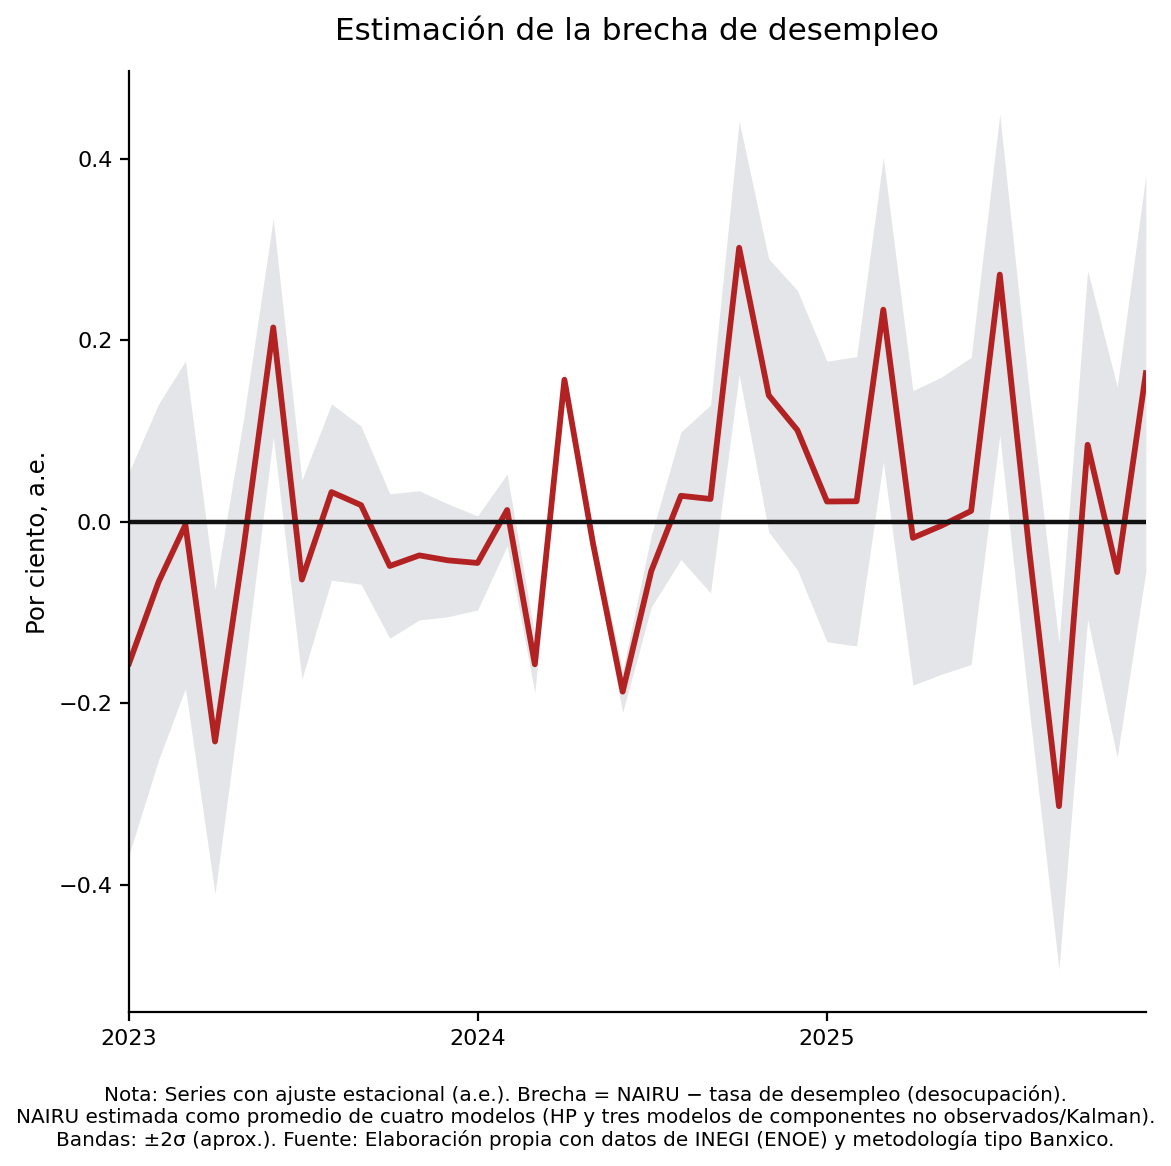

In [17]:
fig, ax = plt.subplots(figsize=(7.8, 7.8), dpi=160)  # CUADRADA

# estilo sobrio
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.tick_params(axis="both", which="both", direction="out", length=4, width=1)

# bandas
ax.fill_between(
    gaps.index,
    gaps["lower"].values,
    gaps["upper"].values,
    color=GRAY,
    alpha=0.18,
    linewidth=0
)

# línea brecha
ax.plot(gaps.index, gaps["gap_mean"], color=RED, lw=2.6)

# línea cero
ax.axhline(0, color=BLACK, lw=2.0)

# ejes y formato x
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title("Estimación de la brecha de desempleo", pad=14)
ax.set_ylabel("Por ciento, a.e.")
ax.set_xlabel("")

ax.set_xlim(gaps.index.min(), gaps.index.max())

note = (
    "Nota: Series con ajuste estacional (a.e.). Brecha = NAIRU − tasa de desempleo (desocupación).\n"
    "NAIRU estimada como promedio de cuatro modelos (HP y tres modelos de componentes no observados/Kalman).\n"
    "Bandas: ±2σ (aprox.). Fuente: Elaboración propia con datos de INEGI (ENOE) y metodología tipo Banxico."
)
fig.text(0.5, 0.02, note, ha="center", va="bottom", fontsize=9)

plt.tight_layout(rect=[0.03, 0.08, 0.97, 0.95])
plt.show()
